## 🏦 Loan Approval Prediction using Decision Tree

### 🎯 Project Objective

The goal of this project is to build a Decision Tree Machine Learning model that predicts whether a loan application will be approved or not based on applicant details like income, credit score, employment status, and loan history.

This helps financial institutions:
- Reduce risky loan approvals
- Automate decision-making
- Understand key factors influencing approvals

### Import required libraries

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Load the dataset

In [197]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\08_decision_tree_loan_approval\data\synthetic_loan_data.csv")

In [198]:
df.head()

,CustomerID,Name,Age,Gender,MaritalStatus,EducationLevel,EmploymentStatus,AnnualIncome,LoanAmountRequested,PurposeOfLoan,CreditScore,ExistingLoansCount,LatePaymentsLastYear,LoanApproved
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Michelle Prince,56,Male,Divorced,Other,Employed,97622,46413,Personal,500,2,4,Yes
1,23b8c1e9-3924-46de-beb1-3b9046685257,Diana Mullins,69,Male,Married,Bachelor,Employed,96925,24065,Home,532,2,0,Yes
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Brittany Ballard,46,Female,Single,High School,Self-employed,167927,46676,Personal,795,2,6,Yes
3,972a8469-1641-4f82-8b9d-2434e465e150,Matthew Freeman,32,Female,Widowed,PhD,Unemployed,112920,27406,Education,376,2,9,No
4,17fc695a-07a0-4a6e-8822-e8f36c031199,Amy Baker,60,Female,Widowed,Master,Unemployed,152183,49337,Car,517,3,7,No


In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CustomerID            9000 non-null   object
 1   Name                  9000 non-null   object
 2   Age                   9000 non-null   int64 
 3   Gender                9000 non-null   object
 4   MaritalStatus         9000 non-null   object
 5   EducationLevel        9000 non-null   object
 6   EmploymentStatus      9000 non-null   object
 7   AnnualIncome          9000 non-null   int64 
 8   LoanAmountRequested   9000 non-null   int64 
 9   PurposeOfLoan         9000 non-null   object
 10  CreditScore           9000 non-null   int64 
 11  ExistingLoansCount    9000 non-null   int64 
 12  LatePaymentsLastYear  9000 non-null   int64 
 13  LoanApproved          9000 non-null   object
dtypes: int64(6), object(8)
memory usage: 984.5+ KB


In [200]:
df.describe()

,Age,AnnualIncome,LoanAmountRequested,CreditScore,ExistingLoansCount,LatePaymentsLastYear
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,43.550444,110279.808556,25680.583333,573.193333,2.008444,4.475444
std,14.909264,52147.330689,14116.494549,158.013843,1.414110,2.878403
min,18.000000,20009.000000,1000.000000,300.000000,0.000000,0.000000
25%,31.000000,65443.250000,13564.750000,437.000000,1.000000,2.000000
50%,43.000000,110331.000000,25814.000000,574.000000,2.000000,4.000000
75%,56.000000,155539.250000,37941.500000,708.000000,3.000000,7.000000
max,69.000000,199988.000000,49989.000000,849.000000,4.000000,9.000000


In [201]:
df.isnull().sum()

CustomerID              0
Name                    0
Age                     0
Gender                  0
MaritalStatus           0
EducationLevel          0
EmploymentStatus        0
AnnualIncome            0
LoanAmountRequested     0
PurposeOfLoan           0
CreditScore             0
ExistingLoansCount      0
LatePaymentsLastYear    0
LoanApproved            0
dtype: int64

### Key Observations

- Dataset contains demographic, financial, and credit-related features
- Target variable: LoanApproved (Yes/No)
- No major missing values (assuming synthetic dataset is clean)

### EDA and key insights

#### Loan approval distribution

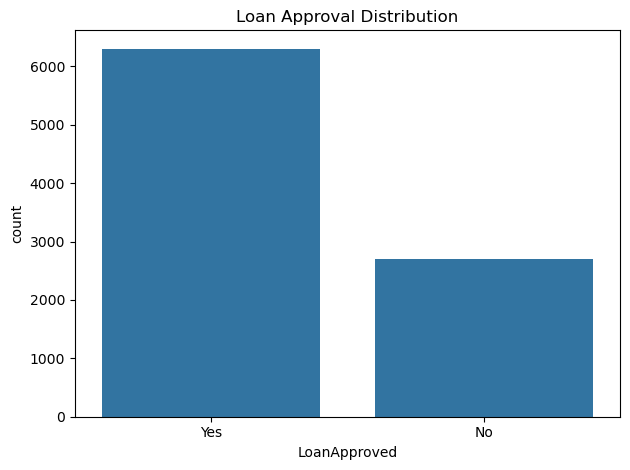

In [202]:
sns.countplot(x='LoanApproved', data=df)
plt.title("Loan Approval Distribution")
plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\08_decision_tree_loan_approval\images\loan_approval_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Insight: Helps understand if the dataset is balanced or skewed toward approvals/rejections.

#### Loan approval rate by credit score band

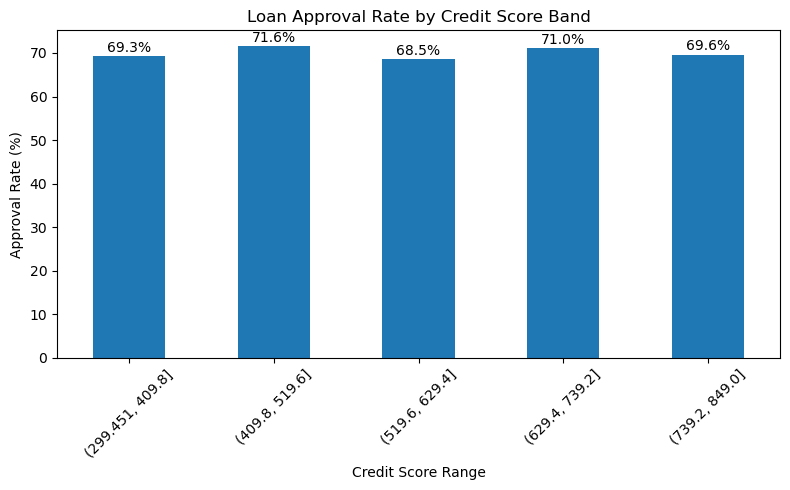

In [203]:
# Create bins
df['CreditScoreBand'] = pd.cut(df['CreditScore'], bins=5)

# Calculate approval rate (percentage of "Yes")
approval_rate = df.groupby('CreditScoreBand', observed=False)['LoanApproved'] \
                  .value_counts(normalize=True).unstack()

approval_rate = approval_rate['Yes'] * 100

# Plot
ax = approval_rate.plot(kind='bar', figsize=(8,5))

plt.title("Loan Approval Rate by Credit Score Band")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Credit Score Range")
plt.xticks(rotation=45)

# Add % labels on top of bars
for i, v in enumerate(approval_rate):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\08_decision_tree_loan_approval\images\loan_approval_by_credit_score.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Insight: 

Although credit score is traditionally a strong lending factor, in this synthetic dataset the approval rate does not drastically increase with higher scores. This indicates that loan approval decisions are influenced by multiple features such as income, employment status, and existing loans — highlighting the need for machine learning rather than rule-based approval.

#### Annual income vs loan approval

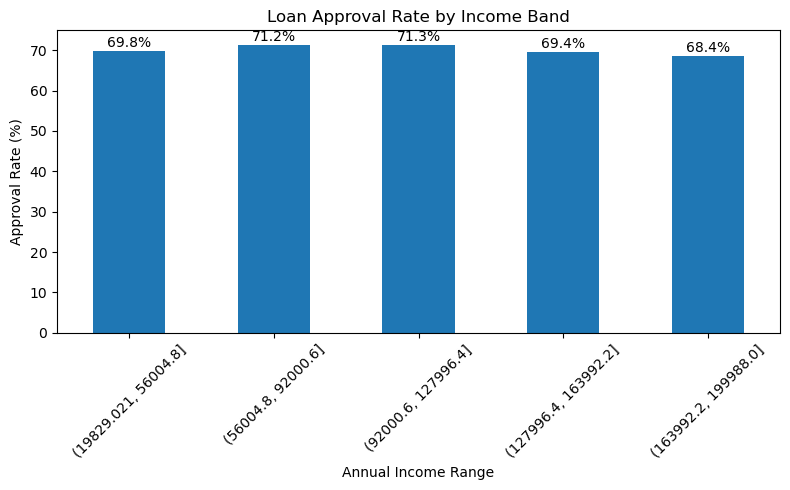

In [204]:
# Create income bands
df['IncomeBand'] = pd.cut(df['AnnualIncome'], bins=5)

# Calculate approval rate (percentage of "Yes")
income_approval_rate = df.groupby('IncomeBand', observed=False)['LoanApproved'] \
                         .value_counts(normalize=True).unstack()

income_approval_rate = income_approval_rate['Yes'] * 100

# Plot
ax = income_approval_rate.plot(kind='bar', figsize=(8,5))

plt.title("Loan Approval Rate by Income Band")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Annual Income Range")
plt.xticks(rotation=45)

# Add % labels on top of bars
for i, v in enumerate(income_approval_rate):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\08_decision_tree_loan_approval\images\loan_approval_by_income.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Insight:

Income alone does not strongly determine loan approval, suggesting that the model considers multiple financial and credit-related features together.

### Data preparation for model

#### Drop irrelevant columns

In [205]:
df = df.drop(columns=['CustomerID', 'Name','PurposeOfLoan','CreditScoreBand', 'IncomeBand'], errors='ignore')

#### Encode Categorical Variables

In [206]:
categorical_cols = ['Gender', 'MaritalStatus', 'EducationLevel', 'EmploymentStatus']


encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

#### Define Features and Target and save feature column order

In [207]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "features.pkl")

['features.pkl']

#### Train-Test Split

In [208]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Machine Learning Model — Decision Tree

In [209]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

#### Prediction with model

In [210]:
y_pred = model.predict(X_test)

### Model evaluation

#### Accuracy

In [211]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6827777777777778


#### Confusion matrix

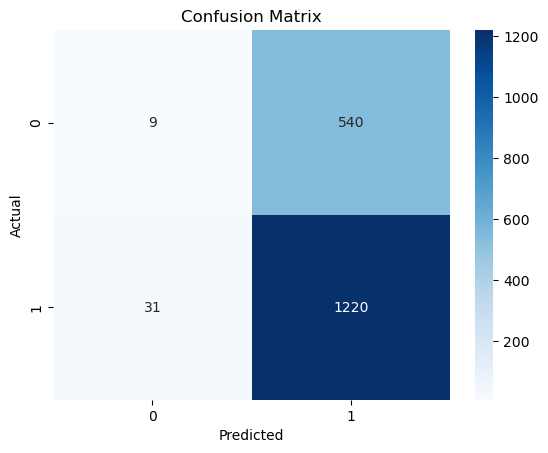

In [212]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Classification report

In [213]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.23      0.02      0.03       549
           1       0.69      0.98      0.81      1251

    accuracy                           0.68      1800
   macro avg       0.46      0.50      0.42      1800
weighted avg       0.55      0.68      0.57      1800



In [214]:
import joblib

joblib.dump(model, "loan_approval_model.pkl")
print("Model saved successfully!")

Model saved successfully!
